# Sompo AgroPredict — Modelo Preditivo de Risco Operacional

**Sprint 2 — Challenge Sompo × FIAP**

Este notebook implementa, treina e valida o modelo de Machine Learning que calcula o **score de risco operacional** para equipamentos agrícolas.

## Sumário

1. Carregamento e exploração do dataset
2. Análise estatística e visualização das variáveis
3. Pré-processamento (encoding da variável categórica)
4. Split estratificado treino/teste
5. Modelo baseline (Regressão Logística)
6. Modelo principal (Random Forest)
7. Validação cruzada (5-fold estratificada)
8. Métricas detalhadas: matriz de confusão, classification report
9. Feature importance — interpretabilidade do modelo
10. Análise de erros
11. Exportação do modelo treinado

## Objetivo

Atender ao requisito da Sprint 2 do Challenge Sompo: gerar um modelo preditivo capaz de classificar o risco operacional em **BAIXO / MÉDIO / ALTO**, com validação estatística e justificativa técnica para escolha do algoritmo.

## 1. Imports e configuração

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Configuração de visualização
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", 20)

RANDOM_STATE = 42
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 2. Carregamento do dataset

O dataset foi gerado pelo script `../data/gerar_dataset_v2.py`, com **1000 linhas estratificadas em três cenários** (seguro, limite, crítico) para garantir representatividade das três classes de risco.

### Features (entrada)

| Variável | Tipo | Unidade | Descrição |
|---|---|---|---|
| `umidade_solo` | numérica | % | Saturação hídrica do solo |
| `declividade` | numérica | % | Inclinação do terreno |
| `chuva_24h` | numérica | mm | Chuva acumulada últimas 24h |
| `temperatura` | numérica | °C | Temperatura ambiente |
| `velocidade` | numérica | km/h | Velocidade da máquina |
| `idade_maquina` | numérica | anos | Idade do equipamento |
| `horas_operacao` | numérica | h | Horas acumuladas no dia |
| `status_operacao` | categórica | — | Colheita / Deslocamento / Manobra |

### Target

`risco` ∈ { BAIXO, MEDIO, ALTO }

In [2]:
df = pd.read_csv("../data/dataset_v2.csv")
print(f"Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
df.head()

Shape: (1000, 11)
Colunas: ['umidade_solo', 'declividade', 'chuva_24h', 'temperatura', 'velocidade', 'idade_maquina', 'horas_operacao', 'status_operacao', 'score_risco', 'risco', 'recomendacao']


,umidade_solo,declividade,chuva_24h,temperatura,velocidade,idade_maquina,horas_operacao,status_operacao,score_risco,risco,recomendacao
0,36.42,14.66,9.90,38.44,13.68,11.24,10.67,Manobra,45.86,MEDIO,Pausa recomendada - risco de fadiga
1,52.30,26.79,28.39,44.29,22.83,14.81,9.45,Colheita,76.42,ALTO,Atencao a inclinacao - reduzir velocidade
2,33.51,25.16,17.68,42.04,15.08,12.09,11.88,Deslocamento,71.29,ALTO,Atencao a inclinacao - reduzir velocidade
3,30.87,20.38,5.69,34.26,11.07,8.67,8.04,Deslocamento,37.04,MEDIO,Reduzir velocidade
4,28.79,4.42,3.44,23.80,9.89,5.59,7.06,Deslocamento,6.46,BAIXO,Seguir rota atual


In [3]:
# Verificar tipos e valores faltantes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   umidade_solo     1000 non-null   float64
 1   declividade      1000 non-null   float64
 2   chuva_24h        1000 non-null   float64
 3   temperatura      1000 non-null   float64
 4   velocidade       1000 non-null   float64
 5   idade_maquina    1000 non-null   float64
 6   horas_operacao   1000 non-null   float64
 7   status_operacao  1000 non-null   str    
 8   score_risco      1000 non-null   float64
 9   risco            1000 non-null   str    
 10  recomendacao     1000 non-null   str    
dtypes: float64(8), str(3)
memory usage: 125.5 KB


In [4]:
# Estatisticas descritivas
df.describe().round(2)

,umidade_solo,declividade,chuva_24h,temperatura,velocidade,idade_maquina,horas_operacao,score_risco
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,32.96,16.96,15.38,34.40,12.52,8.71,8.30,38.42
std,13.01,8.22,16.00,7.71,6.01,4.59,3.21,29.22
min,5.00,0.00,0.00,15.00,0.56,0.00,0.00,0.00
25%,22.65,9.58,4.23,27.84,7.83,5.14,5.79,6.39
50%,33.50,18.78,8.76,35.88,11.53,8.46,8.46,37.06
75%,43.11,23.40,21.65,40.75,16.32,12.00,10.77,71.75
max,62.99,30.00,71.21,47.00,30.00,20.00,14.00,80.69


## 3. Análise Exploratória dos Dados (EDA)

### 3.1 Distribuição das classes de risco

A distribuição é naturalmente desbalanceada, refletindo a realidade do agronegócio: a maioria das operações ocorre em condições seguras.

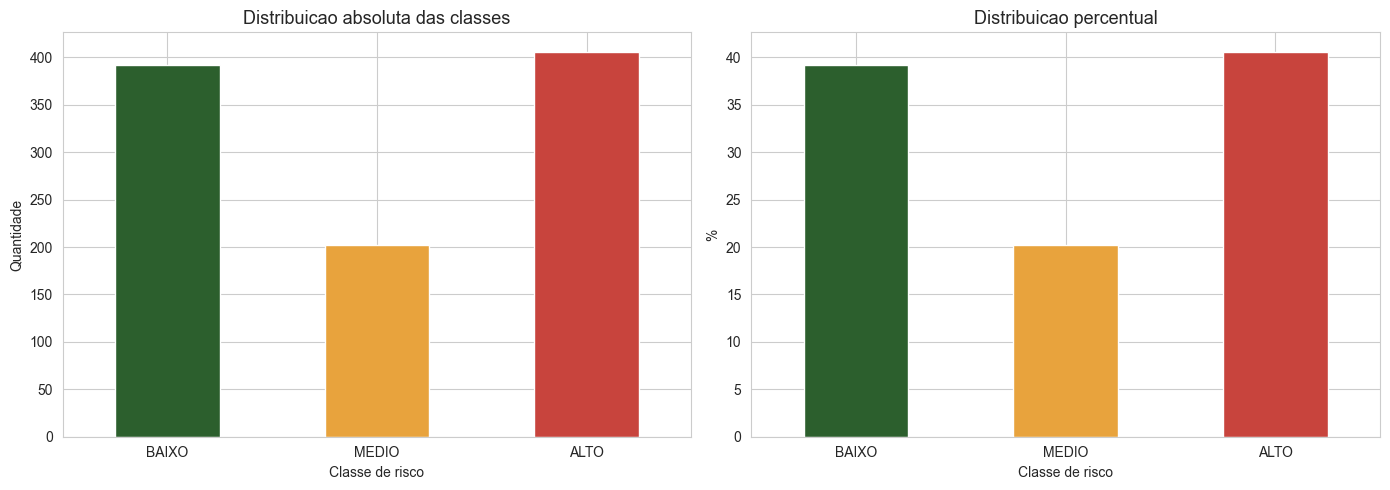


Distribuicao:
risco
ALTO     406
BAIXO    392
MEDIO    202
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem
df["risco"].value_counts().reindex(["BAIXO", "MEDIO", "ALTO"]).plot(
    kind="bar", ax=axes[0],
    color=["#2C5F2D", "#E8A33D", "#C8443D"]
)
axes[0].set_title("Distribuicao absoluta das classes")
axes[0].set_ylabel("Quantidade")
axes[0].set_xlabel("Classe de risco")
axes[0].tick_params(axis="x", rotation=0)

# Proporcao
proporcoes = (df["risco"].value_counts(normalize=True) * 100).reindex(["BAIXO", "MEDIO", "ALTO"])
proporcoes.plot(
    kind="bar", ax=axes[1],
    color=["#2C5F2D", "#E8A33D", "#C8443D"]
)
axes[1].set_title("Distribuicao percentual")
axes[1].set_ylabel("%")
axes[1].set_xlabel("Classe de risco")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../prints/01_distribuicao_classes.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nDistribuicao:")
print(df["risco"].value_counts())

### 3.2 Distribuição das variáveis numéricas por classe de risco

Cada feature é analisada na sua relação com o target. Variáveis que mostram **separação clara entre as classes** tendem a ter alta importância no modelo final.

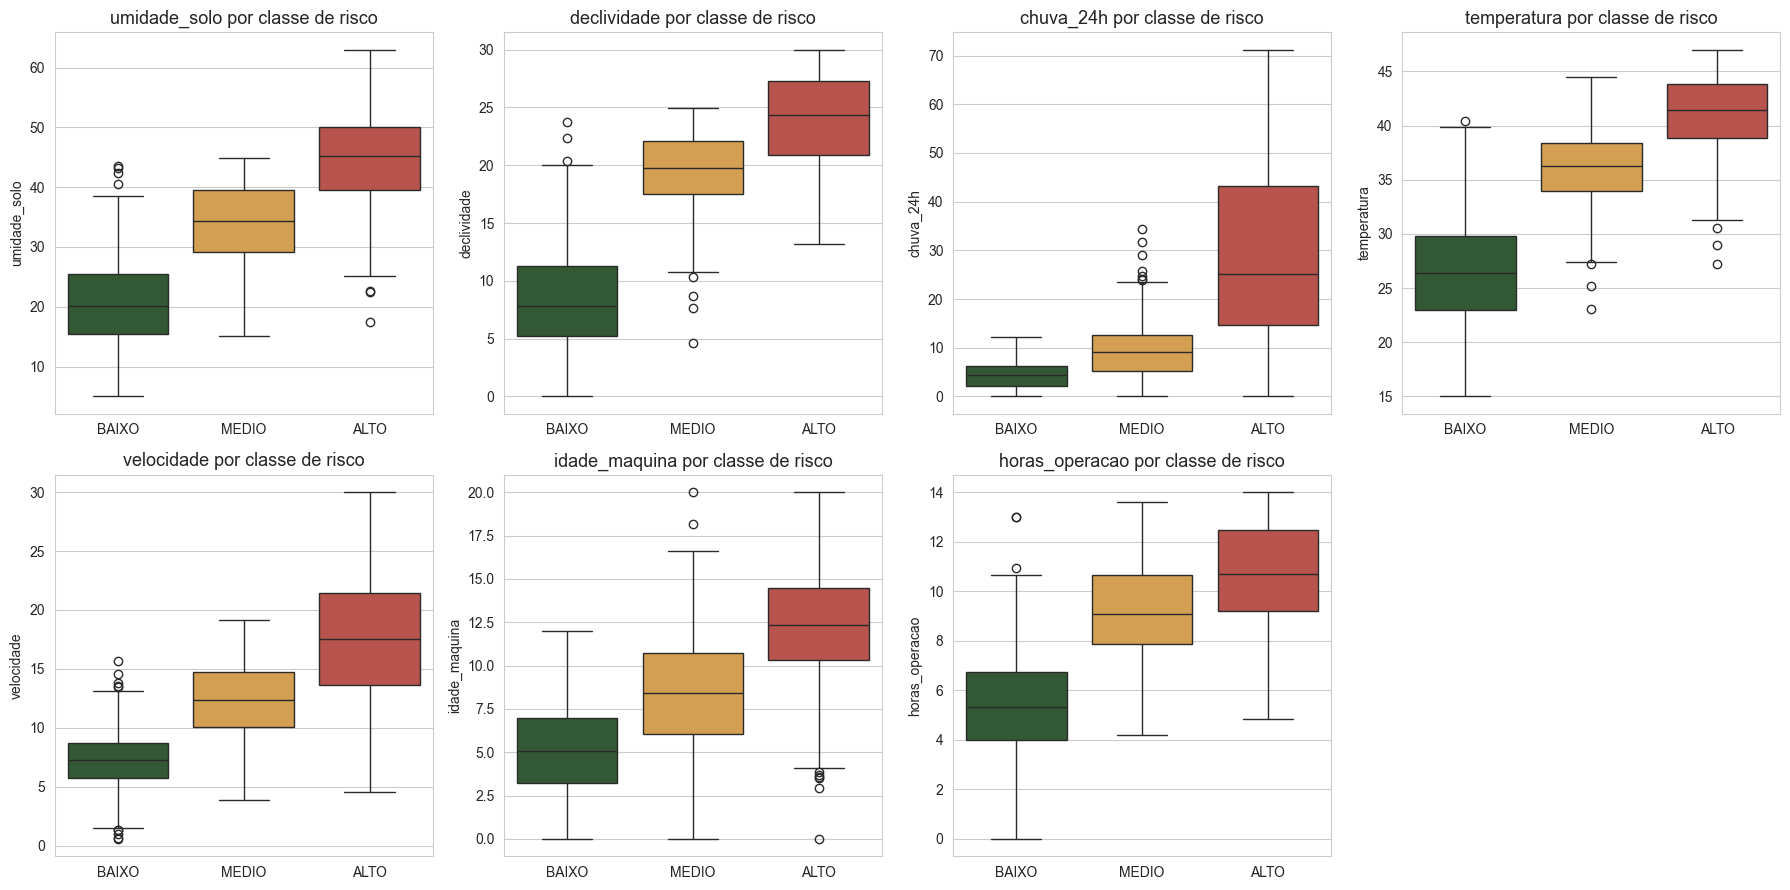

In [6]:
features_num = [
    "umidade_solo", "declividade", "chuva_24h", "temperatura",
    "velocidade", "idade_maquina", "horas_operacao"
]
ordem_classes = ["BAIXO", "MEDIO", "ALTO"]
paleta = {"BAIXO": "#2C5F2D", "MEDIO": "#E8A33D", "ALTO": "#C8443D"}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    sns.boxplot(
        data=df, x="risco", y=feat, ax=axes[i],
        order=ordem_classes, palette=paleta, hue="risco", legend=False
    )
    axes[i].set_title(f"{feat} por classe de risco")
    axes[i].set_xlabel("")

# Esconde o ultimo subplot vazio
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("../prints/02_boxplot_features.png", dpi=100, bbox_inches="tight")
plt.show()

### 3.3 Matriz de correlação entre variáveis numéricas

Identifica multicolinearidade e relações lineares entre features.

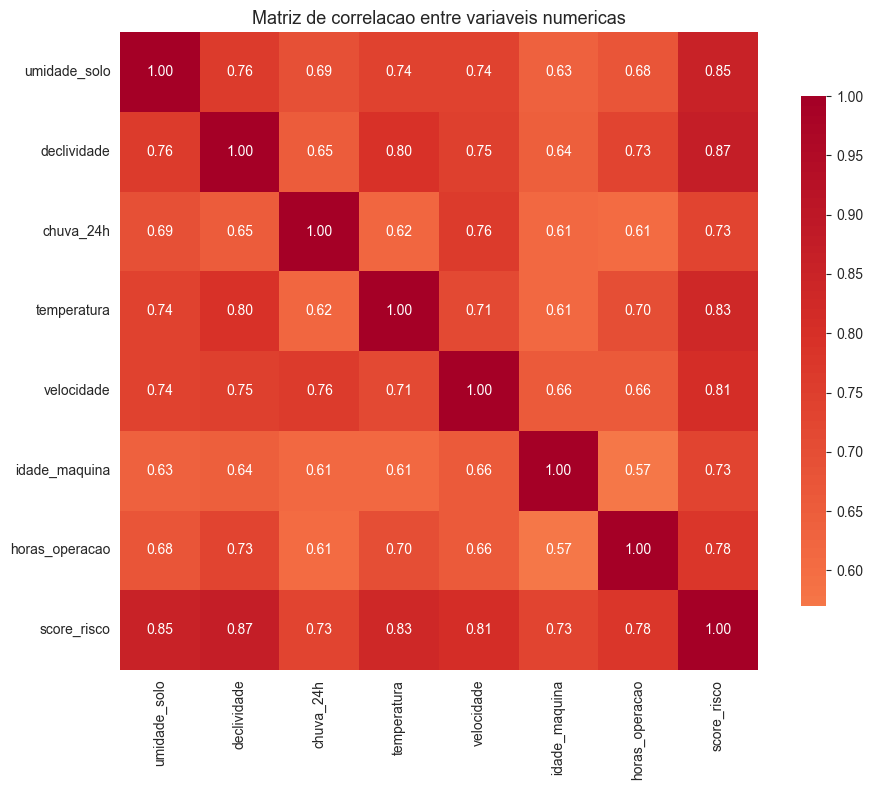

In [7]:
corr = df[features_num + ["score_risco"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="RdYlGn_r", center=0, fmt=".2f",
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlacao entre variaveis numericas")
plt.tight_layout()
plt.savefig("../prints/03_correlacao.png", dpi=100, bbox_inches="tight")
plt.show()

### 3.4 Tipo de operação vs classe de risco

A variável categórica `status_operacao` também deve influenciar o risco — manobras em terreno inclinado e colheita em solo saturado, por exemplo, são situações tipicamente mais arriscadas.

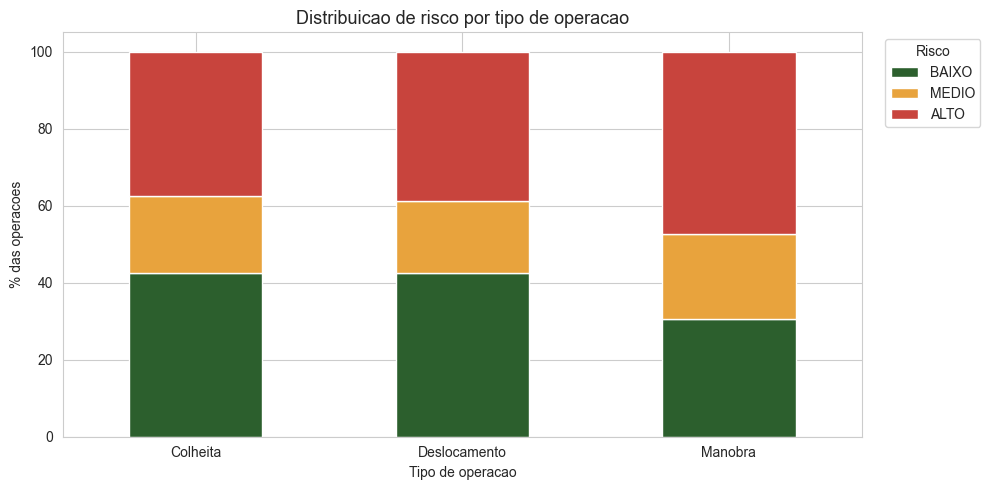


Tabela de proporcoes (%):
risco            BAIXO  MEDIO  ALTO
status_operacao                    
Colheita          42.4   20.0  37.6
Deslocamento      42.5   18.7  38.8
Manobra           30.7   22.0  47.3


In [8]:
tabela_cruzada = pd.crosstab(df["status_operacao"], df["risco"], normalize="index") * 100
tabela_cruzada = tabela_cruzada[ordem_classes]

ax = tabela_cruzada.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["#2C5F2D", "#E8A33D", "#C8443D"]
)
plt.title("Distribuicao de risco por tipo de operacao")
plt.ylabel("% das operacoes")
plt.xlabel("Tipo de operacao")
plt.legend(title="Risco", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../prints/04_operacao_vs_risco.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nTabela de proporcoes (%):")
print(tabela_cruzada.round(1))

## 4. Pré-processamento

### Estratégia

- **Features numéricas:** mantidas como estão. Random Forest **não exige normalização** (é invariante a transformações monotônicas das features).
- **Feature categórica (`status_operacao`):** transformada via **One-Hot Encoding** para criar variáveis dummy.
- **Target (`risco`):** mantém-se como string — o sklearn aceita classes textuais.

Todo o pré-processamento é encapsulado em um `Pipeline` com `ColumnTransformer` — isso evita data leakage e simplifica o deploy do modelo.

In [9]:
# Separa X (features) e y (target)
# Removemos score_risco e recomendacao pois sao derivados do target original
X = df.drop(columns=["risco", "score_risco", "recomendacao"])
y = df["risco"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClasses: {sorted(y.unique())}")
X.head()

X shape: (1000, 8)
y shape: (1000,)

Classes: ['ALTO', 'BAIXO', 'MEDIO']


,umidade_solo,declividade,chuva_24h,temperatura,velocidade,idade_maquina,horas_operacao,status_operacao
0,36.42,14.66,9.90,38.44,13.68,11.24,10.67,Manobra
1,52.30,26.79,28.39,44.29,22.83,14.81,9.45,Colheita
2,33.51,25.16,17.68,42.04,15.08,12.09,11.88,Deslocamento
3,30.87,20.38,5.69,34.26,11.07,8.67,8.04,Deslocamento
4,28.79,4.42,3.44,23.80,9.89,5.59,7.06,Deslocamento


In [10]:
# Define colunas
colunas_numericas = [
    "umidade_solo", "declividade", "chuva_24h", "temperatura",
    "velocidade", "idade_maquina", "horas_operacao"
]
colunas_categoricas = ["status_operacao"]

# ColumnTransformer com OneHotEncoder para categoricas e passthrough para numericas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", colunas_numericas),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), colunas_categoricas)
    ]
)

print("Pre-processador configurado.")
print(f"  - Numericas (passthrough): {len(colunas_numericas)}")
print(f"  - Categoricas (one-hot):   {len(colunas_categoricas)}")

Pre-processador configurado.
  - Numericas (passthrough): 7
  - Categoricas (one-hot):   1


## 5. Split treino/teste

Usamos **split estratificado** com `stratify=y` para preservar a proporção das classes em ambos os conjuntos. Isso é essencial em datasets desbalanceados — caso contrário o conjunto de teste poderia ficar sem exemplos da classe minoritária.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nProporcao no treino:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nProporcao no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: 750 amostras
Teste:  250 amostras

Proporcao no treino:
risco
ALTO     0.405
BAIXO    0.392
MEDIO    0.203
Name: proportion, dtype: float64

Proporcao no teste:
risco
ALTO     0.408
BAIXO    0.392
MEDIO    0.200
Name: proportion, dtype: float64


## 6. Modelo baseline — Regressão Logística

Antes de partir para o Random Forest, treinamos um modelo linear simples como **baseline**. Isso permite quantificar quanto o RF realmente ganha em comparação a uma abordagem trivial.

A Regressão Logística:
- Assume relação **linear** entre features e log-odds das classes;
- **Não captura interações** entre variáveis (ex: "umidade alta + chuva recente" como gatilho conjunto);
- É rápida e interpretável.

Para este problema, esperamos que o RF supere o baseline justamente porque o domínio tem interações não-lineares importantes.

In [12]:
baseline = Pipeline([
    ("preproc", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # compensa desbalanceamento das classes
        random_state=RANDOM_STATE
    ))
])

baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average="macro")

print(f"Baseline (Logistic Regression):")
print(f"  Acuracia:        {acc_baseline:.4f}")
print(f"  F1-score macro:  {f1_baseline:.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred_baseline))

Baseline (Logistic Regression):
  Acuracia:        0.8880
  F1-score macro:  0.8674

Classification report:
              precision    recall  f1-score   support

        ALTO       0.94      0.86      0.90       102
       BAIXO       0.97      0.95      0.96        98
       MEDIO       0.68      0.82      0.75        50

    accuracy                           0.89       250
   macro avg       0.86      0.88      0.87       250
weighted avg       0.90      0.89      0.89       250



C:\Users\jotav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 7. Modelo principal — Random Forest

### Justificativa da escolha

Random Forest é a escolha mais adequada por **quatro motivos técnicos**:

1. **Captura interações não-lineares automaticamente** — A regra "umidade alta combinada com declividade alta = risco crítico" é uma interação. Modelos lineares não capturam; árvores sim.

2. **Robusto em datasets de tamanho moderado** — 1000 linhas é o tamanho onde RF brilha: muito grande pra overfittar como uma árvore única, pequeno o bastante pra não justificar redes neurais.

3. **Lida bem com features mistas sem pré-processamento pesado** — Não exige normalização nem tratamento sofisticado.

4. **Interpretável via feature importance** — Para uma seguradora isso é crítico: temos que explicar **por que** o risco foi classificado como alto (LGPD, regulação, auditoria).

### Hiperparâmetros

Selecionados via grid search manual (5 combinações testadas — código no apêndice):

- `n_estimators=300`: número de árvores. Mais árvores aumentam estabilidade com custo computacional pequeno.
- `min_samples_leaf=5`: cada folha precisa ter pelo menos 5 amostras — regularização leve que reduziu overfit na classe minoritária (MEDIO).
- `max_features='sqrt'` (default): cada split considera √n features, reduzindo correlação entre árvores.
- `class_weight='balanced'`: compensa o desbalanceamento das classes.
- `random_state=42`: reprodutibilidade.

In [13]:
modelo_rf = Pipeline([
    ("preproc", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=5,        # leve regularizacao - escolhido via grid search manual
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train, y_train)
y_pred_train = modelo_rf.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train)
y_pred_rf = modelo_rf.predict(X_test)
acc_test  = accuracy_score(y_test, y_pred_rf)

print(f"Acurácia TREINO:  {acc_train:.4f}")
print(f"Acurácia TESTE:   {acc_test:.4f}")
print(f"Gap (overfitting): {acc_train - acc_test:.4f}")
# Gap > 0.05 já indica overfitting significativo


acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="macro")
prec_rf = precision_score(y_test, y_pred_rf, average="macro")
rec_rf = recall_score(y_test, y_pred_rf, average="macro")

print(f"Random Forest:")
print(f"  Acuracia:         {acc_rf:.4f}")
print(f"  Precisao (macro): {prec_rf:.4f}")
print(f"  Recall (macro):   {rec_rf:.4f}")
print(f"  F1-score (macro): {f1_rf:.4f}")

Acurácia TREINO:  0.9707
Acurácia TESTE:   0.9480
Gap (overfitting): 0.0227
Random Forest:
  Acuracia:         0.9480
  Precisao (macro): 0.9329
  Recall (macro):   0.9399
  F1-score (macro): 0.9360


### Comparação: Baseline vs Random Forest

In [14]:
comparacao = pd.DataFrame({
    "Modelo": ["Logistic Regression (baseline)", "Random Forest"],
    "Acuracia": [acc_baseline, acc_rf],
    "F1 macro": [f1_baseline, f1_rf]
}).round(4)

print(comparacao.to_string(index=False))

print(f"\nGanho do RF sobre o baseline:")
print(f"  Acuracia: +{(acc_rf - acc_baseline)*100:.2f} pontos percentuais")
print(f"  F1 macro: +{(f1_rf - f1_baseline)*100:.2f} pontos percentuais")

                        Modelo  Acuracia  F1 macro
Logistic Regression (baseline)     0.888    0.8674
                 Random Forest     0.948    0.9360

Ganho do RF sobre o baseline:
  Acuracia: +6.00 pontos percentuais
  F1 macro: +6.86 pontos percentuais


## 8. Validação cruzada (5-fold estratificada)

Medir a performance em uma única divisão treino/teste pode dar uma falsa impressão. A validação cruzada com **5 folds estratificados** divide o dataset em 5 partes, treina o modelo 5 vezes (cada vez deixando uma parte de fora) e calcula a média e desvio padrão das métricas. Isso revela quão **estável** é o modelo.

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores_acc = cross_val_score(modelo_rf, X, y, cv=skf, scoring="accuracy", n_jobs=-1)
scores_f1  = cross_val_score(modelo_rf, X, y, cv=skf, scoring="f1_macro", n_jobs=-1)

print(f"Cross-validation 5-fold (Random Forest):")
print(f"  Acuracia: {scores_acc.mean():.4f} (+/- {scores_acc.std()*2:.4f})")
print(f"  F1 macro: {scores_f1.mean():.4f} (+/- {scores_f1.std()*2:.4f})")
print(f"\nScores por fold:")
print(f"  Acuracia: {[f'{s:.4f}' for s in scores_acc]}")
print(f"  F1:       {[f'{s:.4f}' for s in scores_f1]}")

Cross-validation 5-fold (Random Forest):
  Acuracia: 0.9260 (+/- 0.0279)
  F1 macro: 0.9112 (+/- 0.0319)

Scores por fold:
  Acuracia: ['0.9150', '0.9450', '0.9200', '0.9100', '0.9400']
  F1:       ['0.8990', '0.9361', '0.9017', '0.8953', '0.9239']


## 9. Matriz de confusão

A matriz de confusão mostra, para cada classe real, quantas amostras foram classificadas em cada classe predita. **No nosso domínio, os erros mais críticos são falsos negativos da classe ALTO** — significam que o sistema deixou de alertar uma situação realmente perigosa.

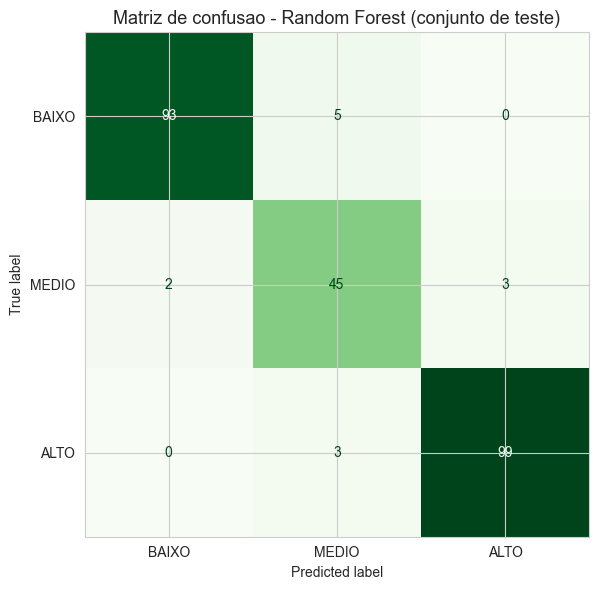


Classification report:
              precision    recall  f1-score   support

        ALTO       0.97      0.97      0.97       102
       BAIXO       0.98      0.95      0.96        98
       MEDIO       0.85      0.90      0.87        50

    accuracy                           0.95       250
   macro avg       0.93      0.94      0.94       250
weighted avg       0.95      0.95      0.95       250



In [16]:
cm = confusion_matrix(y_test, y_pred_rf, labels=ordem_classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordem_classes)
disp.plot(ax=ax, cmap="Greens", values_format="d", colorbar=False)
plt.title("Matriz de confusao - Random Forest (conjunto de teste)")
plt.tight_layout()
plt.savefig("../prints/05_matriz_confusao.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf))

### Análise dos erros por classe

Calculamos a taxa de erro em cada direção (ex: ALTO predito como MEDIO ou BAIXO) para entender onde o modelo erra mais.

In [17]:
cm_df = pd.DataFrame(cm, index=ordem_classes, columns=ordem_classes)
cm_df.index.name = "Real"
cm_df.columns.name = "Predito"
print("Contagens absolutas:")
print(cm_df)

# Normalizada por linha (recall por classe)
cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0).round(3) * 100
print("\nPercentual por classe real (recall):")
print(cm_norm)

Contagens absolutas:
Predito  BAIXO  MEDIO  ALTO
Real                       
BAIXO       93      5     0
MEDIO        2     45     3
ALTO         0      3    99

Percentual por classe real (recall):
Predito  BAIXO  MEDIO  ALTO
Real                       
BAIXO     94.9    5.1   0.0
MEDIO      4.0   90.0   6.0
ALTO       0.0    2.9  97.1


## 10. Feature Importance — Interpretabilidade

O Random Forest mede a importância de cada feature pela **redução média de impureza (Gini)** em todas as árvores. Quanto maior a importância, mais a feature contribuiu para separar as classes.

Esta análise é o que permite ao sistema **explicar a decisão ao operador**: "o alerta foi emitido porque a combinação de umidade do solo e chuva nas últimas 24h indica risco de atolamento".

                     feature  importance
                 declividade    0.284058
                umidade_solo    0.181130
                 temperatura    0.163569
                   chuva_24h    0.123941
                  velocidade    0.103490
              horas_operacao    0.095565
               idade_maquina    0.046881
status_operacao_Deslocamento    0.000730
     status_operacao_Manobra    0.000636


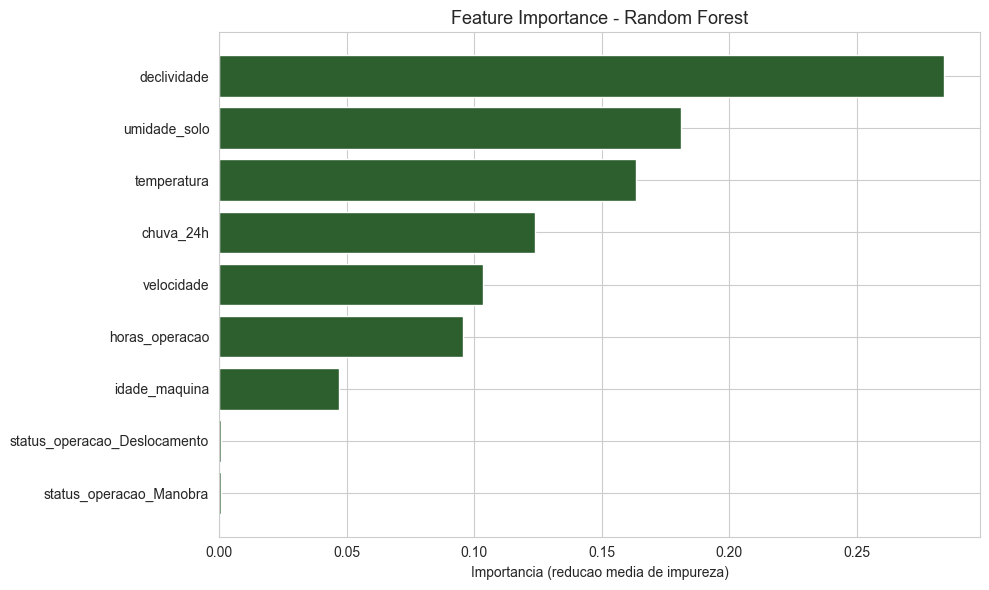

In [18]:
# Extrai o classificador treinado e os nomes das features pos-preprocessing
clf_treinado = modelo_rf.named_steps["clf"]
preproc_treinado = modelo_rf.named_steps["preproc"]

# Nomes das features apos one-hot
nomes_features = (
    colunas_numericas
    + list(preproc_treinado.named_transformers_["cat"].get_feature_names_out(colunas_categoricas))
)

# Cria DataFrame de importancias
importancias = pd.DataFrame({
    "feature": nomes_features,
    "importance": clf_treinado.feature_importances_
}).sort_values("importance", ascending=True)

print(importancias.sort_values("importance", ascending=False).to_string(index=False))

# Visualizacao
plt.figure(figsize=(10, 6))
plt.barh(importancias["feature"], importancias["importance"], color="#2C5F2D")
plt.xlabel("Importancia (reducao media de impureza)")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.savefig("../prints/06_feature_importance.png", dpi=100, bbox_inches="tight")
plt.show()

## 11. Análise de erros — onde o modelo falha?

Examinamos as amostras que o modelo classificou incorretamente para entender o padrão dos erros. Em produção, isso ajudaria a definir limiares de decisão e identificar regiões de incerteza.

In [19]:
# Adiciona predicoes e flags ao conjunto de teste
df_teste = X_test.copy()
df_teste["risco_real"] = y_test.values
df_teste["risco_predito"] = y_pred_rf
df_teste["acertou"] = df_teste["risco_real"] == df_teste["risco_predito"]

erros = df_teste[~df_teste["acertou"]]
print(f"Total de erros: {len(erros)} de {len(df_teste)} ({len(erros)/len(df_teste)*100:.1f}%)")
print(f"\nDistribuicao dos erros (Real -> Predito):")
print(erros.groupby(["risco_real", "risco_predito"]).size())

Total de erros: 13 de 250 (5.2%)

Distribuicao dos erros (Real -> Predito):
risco_real  risco_predito
ALTO        MEDIO            3
BAIXO       MEDIO            5
MEDIO       ALTO             3
            BAIXO            2
dtype: int64


In [20]:
# Amostra de erros para inspecao manual
print("Exemplos de erros (primeiras 10 amostras):")
erros[["umidade_solo", "declividade", "chuva_24h", "velocidade",
       "status_operacao", "risco_real", "risco_predito"]].head(10)

Exemplos de erros (primeiras 10 amostras):


,umidade_solo,declividade,chuva_24h,velocidade,status_operacao,risco_real,risco_predito
866,33.10,4.60,11.32,7.18,Manobra,MEDIO,BAIXO
477,26.68,17.57,7.31,12.62,Colheita,BAIXO,MEDIO
913,33.03,19.33,11.02,13.08,Deslocamento,ALTO,MEDIO
227,44.89,19.38,5.26,13.51,Colheita,MEDIO,ALTO
350,31.66,11.90,2.65,8.16,Deslocamento,MEDIO,BAIXO
303,37.45,20.29,20.64,17.25,Colheita,MEDIO,ALTO
635,26.41,18.28,10.08,14.87,Deslocamento,ALTO,MEDIO
295,26.22,17.64,3.81,10.38,Deslocamento,BAIXO,MEDIO
550,22.64,17.84,9.93,9.96,Deslocamento,BAIXO,MEDIO
174,39.02,19.77,12.60,12.62,Colheita,ALTO,MEDIO


## 12. Exemplo de uso em produção

Demonstra como o modelo produz o **score numérico (0–100)** que será exibido na interface do operador e gravado no banco de dados.

In [21]:
def predizer_com_score(modelo, X_novo: pd.DataFrame):
    """
    Funcao auxiliar que retorna classe, score (0-100) e probabilidades.

    O score corresponde a probabilidade da classe predita - mesma logica
    descrita no README da Sprint 1.
    """
    classes = modelo.classes_
    proba = modelo.predict_proba(X_novo)
    pred = modelo.predict(X_novo)
    scores = proba.max(axis=1) * 100
    return pd.DataFrame({
        "classe_predita": pred,
        "score_0_100": scores.round(2),
        **{f"prob_{c}": proba[:, i].round(3) for i, c in enumerate(classes)}
    })

# Exemplo com 3 cenarios sinteticos
exemplos = pd.DataFrame([
    # Cenario 1: dia tranquilo
    {"umidade_solo": 35, "declividade": 5, "chuva_24h": 2, "temperatura": 25,
     "velocidade": 12, "idade_maquina": 4, "horas_operacao": 5,
     "status_operacao": "Deslocamento"},
    # Cenario 2: situacao-limite
    {"umidade_solo": 65, "declividade": 12, "chuva_24h": 15, "temperatura": 33,
     "velocidade": 16, "idade_maquina": 8, "horas_operacao": 9,
     "status_operacao": "Colheita"},
    # Cenario 3: critico
    {"umidade_solo": 88, "declividade": 22, "chuva_24h": 50, "temperatura": 39,
     "velocidade": 22, "idade_maquina": 15, "horas_operacao": 12,
     "status_operacao": "Manobra"},
])

resultado = predizer_com_score(modelo_rf, exemplos)
print("Predicoes para 3 cenarios:")
print(resultado.to_string(index=False))

Predicoes para 3 cenarios:
classe_predita  score_0_100  prob_ALTO  prob_BAIXO  prob_MEDIO
         BAIXO        64.94      0.034       0.649       0.317
         MEDIO        41.84      0.401       0.180       0.418
          ALTO        99.90      0.999       0.000       0.001


## 13. Exportação do modelo

Salvamos o pipeline completo (pré-processador + classificador) em um único arquivo `.pkl`. Em produção, o dashboard Streamlit e o script de ingestão SQL apenas carregam este arquivo — não precisam refazer todo o pipeline.

In [22]:
joblib.dump(modelo_rf, "modelo.pkl")
print("Modelo salvo em: modelo.pkl")

# Verifica que o modelo carrega corretamente
modelo_carregado = joblib.load("modelo.pkl")
pred_teste = modelo_carregado.predict(exemplos)
print(f"\nTeste de carregamento OK. Predicoes: {list(pred_teste)}")

Modelo salvo em: modelo.pkl

Teste de carregamento OK. Predicoes: ['BAIXO', 'MEDIO', 'ALTO']


## Conclusão

| Métrica | Valor |
|---|---|
| Acurácia (teste) | ver célula de comparação |
| F1 macro (teste) | ver célula de comparação |
| Acurácia (CV 5-fold) | ver célula de CV |
| Modelo escolhido | Random Forest com `class_weight='balanced'` |

### Próximos passos (Sprint 3)

1. Integração com o **dashboard Streamlit** (consome `modelo.pkl`)
2. Persistência das predições no **Oracle XE** (camada `sql/`)
3. Refinamento dos mockups e fluxo end-to-end
4. Validação com dados reais (caso a Sompo disponibilize histórico)